# Mental Health in Tech — Analysis Notebook
**Source:** OSMH Survey (2014–2019) · **Target:** mental_health_mssql on SQL Server Express

In [79]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE = ['#3a86ff','#ff6b6b','#ffd166','#06d6a0','#118ab2','#073b4c']


conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    r'SERVER=LAPTOP-JML1QI0D\SQLEXPRESS;'
    'DATABASE=mental_health_mssql;'
    'Trusted_Connection=yes;'
)
print('Connected:', conn)

Connected: <pyodbc.Connection object at 0x00000158792C3360>


---
## Raw Data Overview
Quick look at the three source tables

In [90]:
df_survey   = pd.read_sql('SELECT * FROM dbo.Survey', conn)
df_question = pd.read_sql('SELECT * FROM dbo.Question', conn)
df_answer   = pd.read_sql('SELECT * FROM dbo.Answer', conn)

print('=== Survey ===')
df_survey.info()
print('=== Description ===')
print(df_survey.describe(include='all'))
print('=== Shape ===')
print(df_survey.shape)

print('=== Question ===')
df_question.info()
print('=== Description ===')
print(df_question.describe(include='all'))
print('=== Shape ===')
print(df_question.shape)

print('=== Answer ===')
df_answer.info()
print('=== Description ===')
print(df_answer.describe(include='all'))
print('=== Shape ===')
print(df_answer.shape)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\291583399.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_survey   = pd.read_sql('SELECT * FROM dbo.Survey', conn)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\291583399.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_question = pd.read_sql('SELECT * FROM dbo.Question', conn)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\291583399.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_answer   = pd.read_sql('SELECT * FROM dbo.Answer', conn)


=== Survey ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SurveyID     5 non-null      int64 
 1   Description  5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes
=== Description ===
           SurveyID                    Description
count      5.000000                              5
unique          NaN                              5
top             NaN  mental health survey for 2014
freq            NaN                              1
mean    2016.800000                            NaN
std        1.923538                            NaN
min     2014.000000                            NaN
25%     2016.000000                            NaN
50%     2017.000000                            NaN
75%     2018.000000                            NaN
max     2019.000000                            NaN
=== Shape ===
(5, 2)
=== Question 

## Data Preprocessing
The data is clean and does not require any preprocessing.

In [81]:
print(df_survey.isna().sum())
print(df_question.isna().sum())
print(df_answer.isna().sum())

SurveyID       0
Description    0
dtype: int64
questionid      0
questiontext    0
dtype: int64
AnswerID      0
AnswerText    0
SurveyID      0
UserID        0
QuestionID    0
dtype: int64


In [82]:
print(df_survey.duplicated().sum())
print(df_question.duplicated().sum())  
print(df_answer.duplicated().sum())

0
0
0


---
## Theme 1 — Stigma Gap
Would you bring up mental vs physical health in a job interview?

In [83]:
query_stigma = """
SELECT 'Mental health' AS Topic, a.AnswerText AS Response, COUNT(*) AS N, CAST(100.0*COUNT(*)/SUM(COUNT(*)) OVER() AS DECIMAL(5,1)) AS Pct
FROM dbo.Answer a 
WHERE a.QuestionID = 12
GROUP BY a.AnswerText

UNION ALL

SELECT 'Physical health', a.AnswerText, COUNT(*), CAST(100.0*COUNT(*)/SUM(COUNT(*)) OVER() AS DECIMAL(5,1))
FROM dbo.Answer a 
WHERE a.QuestionID IN (29, 101)
GROUP BY a.AnswerText
ORDER BY Topic, N DESC;
"""

df_stigma = pd.read_sql(query_stigma, conn)
df_stigma

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\2064008778.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stigma = pd.read_sql(query_stigma, conn)


,Topic,Response,N,Pct
0,Mental health,No,2951,70.0
1,Mental health,Maybe,1036,24.6
2,Mental health,Yes,231,5.5
3,Physical health,Maybe,1823,43.2
4,Physical health,No,1494,35.4
5,Physical health,Yes,901,21.4


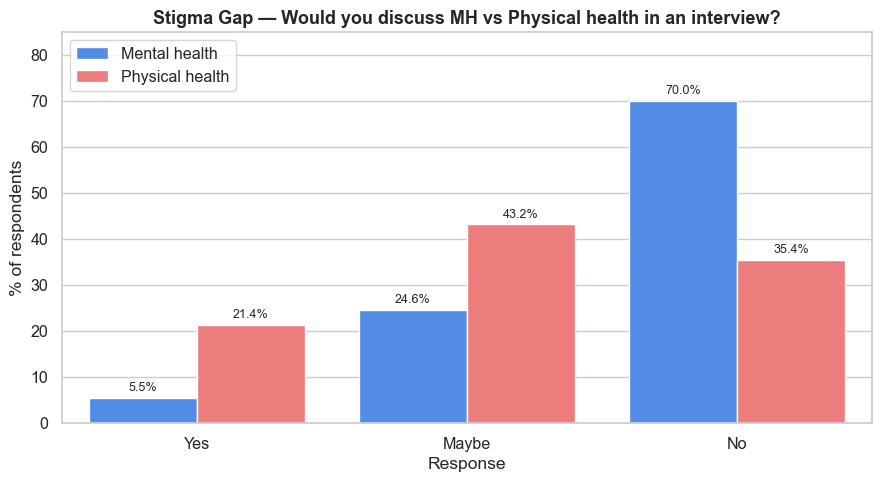

In [84]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ['Yes', 'Maybe', 'No']
sns.barplot(data=df_stigma, x='Response', y='Pct', hue='Topic',
            palette=['#3a86ff', '#ff6b6b'], ax=ax, order=order)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Stigma Gap — Would you discuss MH vs Physical health in an interview?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of respondents')
ax.set_ylim(0, 85)
ax.legend(title='')
plt.tight_layout()
plt.show()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\387757612.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_comfort = pd.read_sql(query_comfort, conn)


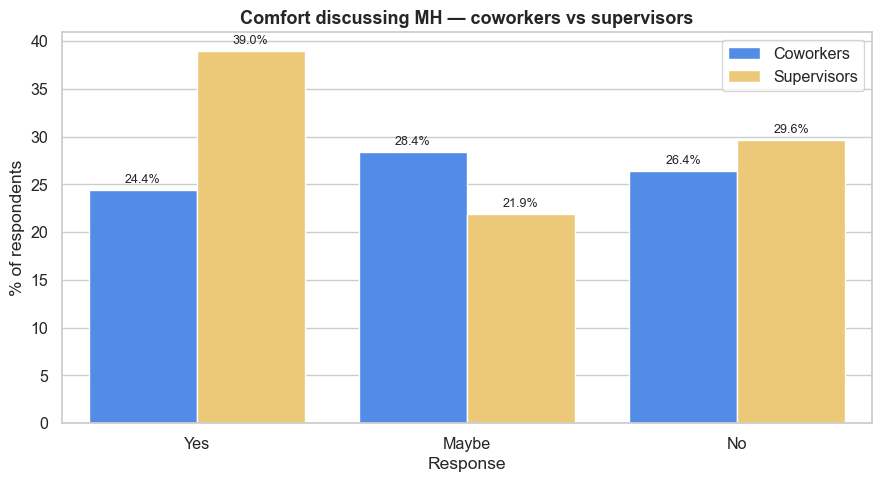

In [85]:
query_comfort = """
SELECT 'Coworkers' AS Audience, AnswerText AS Response, COUNT(*) AS N
FROM dbo.Answer WHERE QuestionID IN (18, 99) AND AnswerText <> '-1'
GROUP BY AnswerText

UNION ALL

SELECT 'Supervisors', AnswerText, COUNT(*)
FROM dbo.Answer WHERE QuestionID IN (19, 100) AND AnswerText <> '-1'
GROUP BY AnswerText
"""

df_comfort = pd.read_sql(query_comfort, conn)
df_comfort['Pct'] = df_comfort.groupby('Audience')['N'].transform(lambda x: x / x.sum() * 100)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_comfort, x='Response', y='Pct', hue='Audience',
            palette=['#3a86ff', '#ffd166'], ax=ax, order=order)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Comfort discussing MH — coworkers vs supervisors',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of respondents')
ax.legend(title='')
plt.tight_layout()
plt.show()

---
## Theme 2 — Prevalence & Treatment
How many people sought treatment? How many report a current disorder?

In [86]:
query_treatment = """
SELECT s.Description AS Survey, CAST(SUM(TRY_CAST(a.AnswerText AS INT))*100.0/COUNT(*) AS DECIMAL(5,1)) AS PctYes, COUNT(*) AS N
FROM dbo.Answer a JOIN dbo.Survey s ON a.SurveyID = s.SurveyID
WHERE a.QuestionID = 7
GROUP BY s.Description ORDER BY s.Description;
"""

query_disorder = """
SELECT
  SUM(CASE WHEN a.AnswerText='Yes' THEN 1 ELSE 0 END) AS [Yes],
  SUM(CASE WHEN a.AnswerText='No' THEN 1 ELSE 0 END) AS [No],
  SUM(CASE WHEN a.AnswerText IN ('Maybe','Possibly') THEN 1 ELSE 0 END) AS [MaybePossibly],
  COUNT(*) AS [Total]
FROM dbo.Answer a
WHERE a.QuestionID = 33
"""

df_treatment = pd.read_sql(query_treatment, conn)
df_disorder  = pd.read_sql(query_disorder, conn)
print(df_treatment)
print()
print(df_disorder)

                          Survey  PctYes     N
0  mental health survey for 2014    50.6  1260
1  mental health survey for 2016    58.5  1433
2  mental health survey for 2017    60.3   756
3  mental health survey for 2018    63.1   417
4  mental health survey for 2019    61.6   352

    Yes   No  MaybePossibly  Total
0  1237  969            628   2958


C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\3476656901.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_treatment = pd.read_sql(query_treatment, conn)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\3476656901.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_disorder  = pd.read_sql(query_disorder, conn)


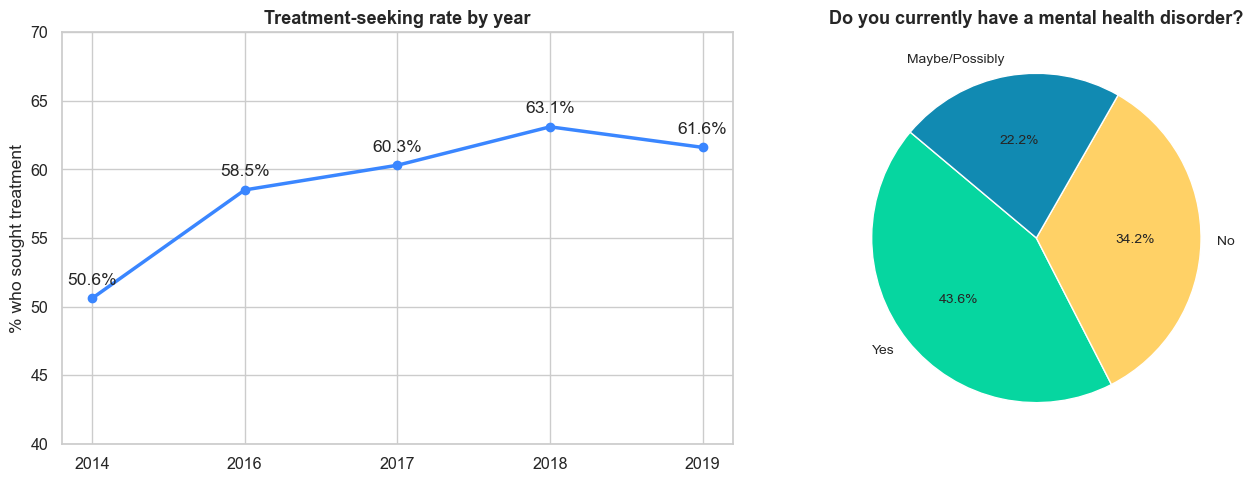

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Treatment by year
axes[0].plot(df_treatment['Survey'].str.extract(r'(\d{4})')[0], df_treatment['PctYes'],
             marker='o', linewidth=2.5, color='#3a86ff')
for _, r in df_treatment.iterrows():
    yr = r['Survey'][-4:]
    axes[0].annotate(f"{r['PctYes']}%", (yr, r['PctYes']),
                     textcoords='offset points', xytext=(0, 10), ha='center')
axes[0].set_title('Treatment-seeking rate by year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% who sought treatment')
axes[0].set_ylim(40, 70)

# Current disorder pie
yes_val   = int(df_disorder["Yes"].iloc[0])
no_val    = int(df_disorder["No"].iloc[0])
maybe_val = int(df_disorder["MaybePossibly"].iloc[0])

sizes  = [yes_val, no_val, maybe_val]
labels = ["Yes", "No", "Maybe/Possibly"]
colours = ['#06d6a0', '#ffd166', '#118ab2', '#ff6b6b']
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%',
             colors=colours, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Do you currently have a mental health disorder?',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Theme 3 — Employer Support
Benefits, anonymity, wellness campaigns, resources, parity

In [ ]:
query_employer = """
SELECT q.questionid AS QuestionID, a.AnswerText AS Response, COUNT(*) AS N
FROM dbo.Answer a , dbo.Question q 
WHERE a.QuestionID = q.questionid AND (a.QuestionID IN (10, 11, 15, 16, 91)) AND a.AnswerText <> '-1'
GROUP BY q.questionid, a.AnswerText
ORDER BY q.questionid, N DESC;
"""

short_labels = {
    10:  'MH benefits offered',
    11:  'Anonymity protected',
    15:  'Wellness campaigns',
    16:  'MH resources provided',
    91:  'MH = physical seriousness',
}

df_employer = pd.read_sql(query_employer, conn)
df_employer['Question'] = df_employer['QuestionID'].map(short_labels)
df_employer

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\1624328635.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_employer = pd.read_sql(query_employer, conn)


,QuestionID,Response,N,Question
0,10,Yes,1744,MH benefits offered
1,10,No,756,MH benefits offered
2,10,I don't know,658,MH benefits offered
3,10,Don't know,408,MH benefits offered
4,10,Not eligible for coverage / NA,148,MH benefits offered
5,11,I don't know,1546,Anonymity protected
6,11,Yes,1135,Anonymity protected
7,11,Don't know,820,Anonymity protected
8,11,No,213,Anonymity protected
9,15,No,1626,Wellness campaigns


C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\2258231434.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_employer['Pct'] = df_employer.groupby('Question')['N'].transform(lambda x: x/x.sum()*100)


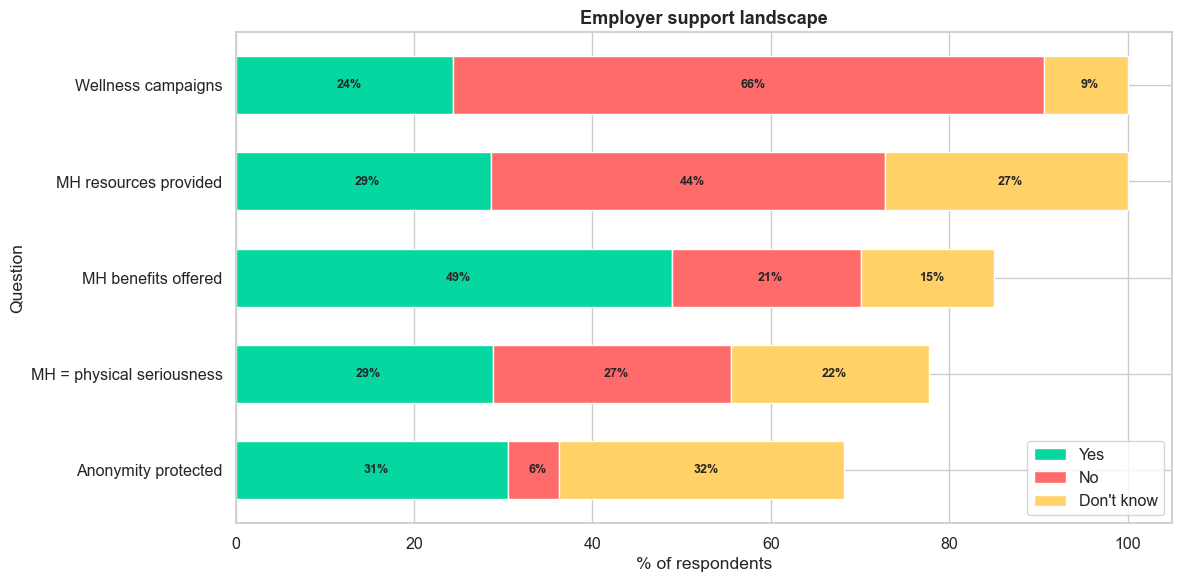

In [ ]:
df_employer.loc[df_employer['Response'].str.lower().str.contains("don't know|don t know", na=False), 'Response'] = "Don't know"
df_employer = df_employer[df_employer['Response'].isin(['Yes', 'No', "Don't know"])]
df_employer['Pct'] = df_employer.groupby('Question')['N'].transform(lambda x: x/x.sum()*100)

pivot = df_employer.pivot_table(index='Question', columns='Response', values='Pct', fill_value=0)
col_order = [c for c in ['Yes', 'No', "Don't know"] if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 6))
col_map = {'Yes': '#06d6a0', 'No': '#ff6b6b', "Don't know": '#ffd166'}
pivot.plot(kind='barh', stacked=True, ax=ax, color=[col_map[c] for c in col_order], width=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=9, fontweight='bold', label_type='center')
ax.set_xlabel('% of respondents')
ax.set_title('Employer support landscape', fontsize=13, fontweight='bold')
ax.legend(title='', loc='lower right')
plt.tight_layout()
plt.show()

---
## Theme 4 — Career Risk
Fear of negative consequences vs observed reality

In [ ]:
query_risk = """
SELECT 'Fear (personal)' AS Source, AnswerText AS Response, COUNT(*) AS N, CAST(100.0*COUNT(*)/SUM(COUNT(*)) OVER() AS DECIMAL(5,1)) AS Pct
FROM dbo.Answer 
WHERE QuestionID IN (98,104) AND AnswerText <> '-1'
GROUP BY AnswerText

UNION ALL

SELECT 'Observed in others', AnswerText, COUNT(*), CAST(100.0*COUNT(*)/SUM(COUNT(*)) OVER() AS DECIMAL(5,1))
FROM dbo.Answer 
WHERE QuestionID IN (102,105)
GROUP BY AnswerText;
"""

df_risk = pd.read_sql(query_risk, conn)
df_risk

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\926489319.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_risk = pd.read_sql(query_risk, conn)


,Source,Response,N,Pct
0,Fear (personal),Maybe,964,40.1
1,Fear (personal),No,928,38.6
2,Fear (personal),Yes,514,21.4
3,Observed in others,-1,287,10.7
4,Observed in others,No,2123,78.8
5,Observed in others,Yes,283,10.5


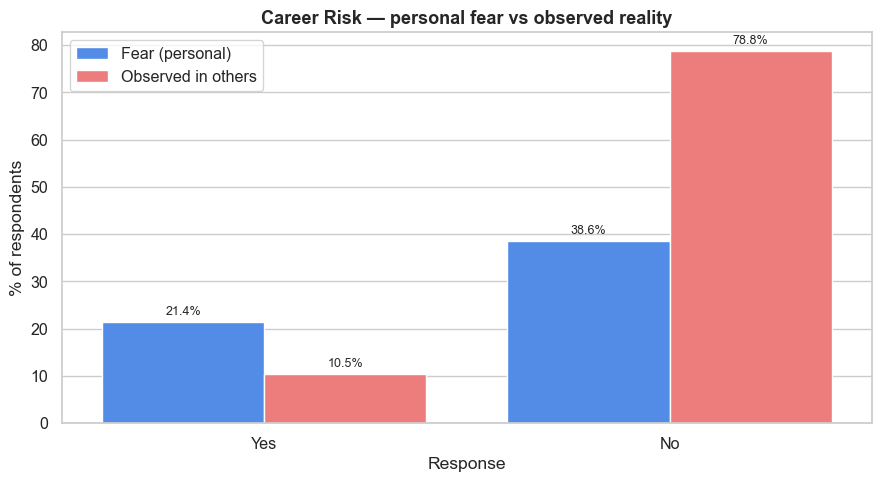

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_risk[df_risk['Response'].isin(['Yes', 'No'])],
            x='Response', y='Pct', hue='Source',
            palette=['#3a86ff', '#ff6b6b'], ax=ax, order=['Yes', 'No'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Career Risk — personal fear vs observed reality',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of respondents')
ax.legend(title='')
plt.tight_layout()
plt.show()

---
## Theme 5 — Work Impact & Productivity
Interference when treated vs untreated; % of work time lost

In [ ]:
query_interfere = """
SELECT 'When treated' AS State, a.AnswerText AS Frequency, COUNT(*) AS N
FROM dbo.Answer a WHERE a.QuestionID = 48 AND a.AnswerText <> 'Not applicable to me'
GROUP BY a.AnswerText

UNION ALL

SELECT 'When untreated', a.AnswerText, COUNT(*)
FROM dbo.Answer a WHERE a.QuestionID = 49 AND a.AnswerText <> 'Not applicable to me'
GROUP BY a.AnswerText
ORDER BY State, N DESC;
"""

query_pct = """
SELECT a.AnswerText AS Bucket, COUNT(*) AS N
FROM dbo.Answer a 
WHERE a.QuestionID = 55 AND a.AnswerText <> '-1'
GROUP BY a.AnswerText ORDER BY a.AnswerText;
"""

df_interfere = pd.read_sql(query_interfere, conn)
df_pct = pd.read_sql(query_pct, conn)
print(df_interfere)
print()
print(df_pct)

            State  Frequency     N
0    When treated  Sometimes   808
1    When treated     Rarely   700
2    When treated      Often   166
3    When treated      Never   165
4  When untreated      Often  1183
5  When untreated  Sometimes   672
6  When untreated     Rarely   113
7  When untreated      Never    24

    Bucket    N
0    1-25%  164
1   26-50%  125
2   51-75%   53
3  76-100%   25


C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\3159699341.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_interfere = pd.read_sql(query_interfere, conn)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\3159699341.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pct = pd.read_sql(query_pct, conn)


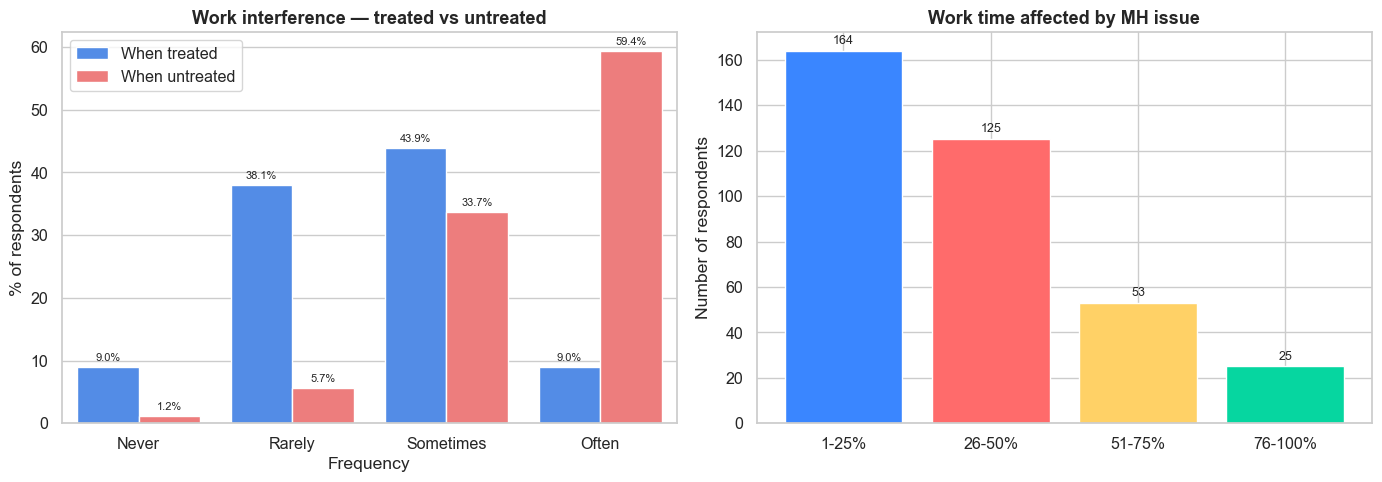

In [ ]:
freq_order = ['Never', 'Rarely', 'Sometimes', 'Often']
df_interfere['Pct'] = df_interfere.groupby('State')['N'].transform(lambda x: x/x.sum()*100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Interference
sns.barplot(data=df_interfere, x='Frequency', y='Pct', hue='State',
            palette=['#3a86ff', '#ff6b6b'], ax=axes[0], order=freq_order)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)
axes[0].set_title('Work interference — treated vs untreated',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('% of respondents')
axes[0].legend(title='')

# % time affected
axes[1].bar(df_pct['Bucket'], df_pct['N'], color=PALETTE[:len(df_pct)])
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
axes[1].set_title('Work time affected by MH issue',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of respondents')

plt.tight_layout()
plt.show()

---
## Theme 6 — Year-over-Year Trends
Key metrics tracked across all five survey years

In [ ]:
query_trends = """
SELECT s.Description,
  CAST(100.0*SUM(CASE WHEN a.QuestionID=7 AND a.AnswerText='1' THEN 1 END)
       /NULLIF(SUM(CASE WHEN a.QuestionID=7 THEN 1 END),0) AS DECIMAL(5,1)) AS TreatmentSeeking,

  CAST(100.0*SUM(CASE WHEN a.QuestionID=33 AND a.AnswerText='Yes' THEN 1 END)
       /NULLIF(SUM(CASE WHEN a.QuestionID=33 THEN 1 END),0) AS DECIMAL(5,1)) AS CurrentDisorder,

  CAST(100.0*SUM(CASE WHEN a.QuestionID=12 AND a.AnswerText='Yes' THEN 1 END)
       /NULLIF(SUM(CASE WHEN a.QuestionID=12 THEN 1 END),0) AS DECIMAL(5,1)) AS InterviewMH_Yes,

  CAST(100.0*SUM(CASE WHEN a.QuestionID IN (19,100) AND a.AnswerText='Yes' THEN 1 END)
       /NULLIF(SUM(CASE WHEN a.QuestionID IN (19,100) THEN 1 END),0) AS DECIMAL(5,1)) AS ComfortSupervisor,
       
  CAST(100.0*SUM(CASE WHEN a.QuestionID=10 AND a.AnswerText='Yes' THEN 1 END)
       /NULLIF(SUM(CASE WHEN a.QuestionID=10 THEN 1 END),0) AS DECIMAL(5,1)) AS BenefitsYes

FROM dbo.Answer a ,dbo.Survey s 
WHERE a.SurveyID = s.SurveyID
GROUP BY s.Description ORDER BY s.Description;
"""

df_trends = pd.read_sql(query_trends, conn)
df_trends['Year'] = df_trends['Description'].str.extract(r'(\d{4})')[0]
df_trends

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7848\390058468.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trends = pd.read_sql(query_trends, conn)


,Description,TreatmentSeeking,CurrentDisorder,InterviewMH_Yes,ComfortSupervisor,BenefitsYes,Year
0,mental health survey for 2014,50.6,NaN,3.5,41.0,37.9,2014
1,mental health survey for 2016,58.5,40.1,7.8,29.9,37.1,2016
2,mental health survey for 2017,60.3,42.9,5.0,33.9,47.5,2017
3,mental health survey for 2018,63.1,45.8,4.8,31.4,51.1,2018
4,mental health survey for 2019,61.6,41.8,4.8,33.2,46.6,2019


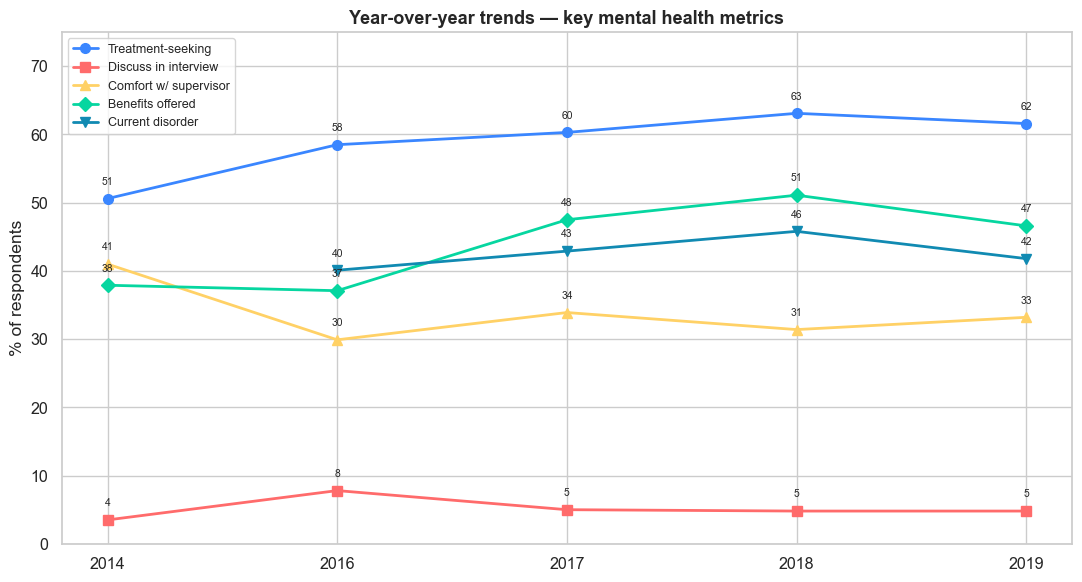

In [ ]:
metrics = [
    ('TreatmentSeeking',  'Treatment-seeking',    '#3a86ff', 'o'),
    ('InterviewMH_Yes',   'Discuss in interview',  '#ff6b6b', 's'),
    ('ComfortSupervisor', 'Comfort w/ supervisor', '#ffd166', '^'),
    ('BenefitsYes',       'Benefits offered',      '#06d6a0', 'D'),
    ('CurrentDisorder',   'Current disorder',      '#118ab2', 'v'),
]

fig, ax = plt.subplots(figsize=(11, 6))
for col, label, colour, marker in metrics:
    ax.plot(df_trends['Year'], df_trends[col], marker=marker, linewidth=2,
            label=label, color=colour, markersize=7)
    for _, r in df_trends.iterrows():
        if pd.notna(r[col]):
            ax.annotate(f"{r[col]:.0f}", (r['Year'], r[col]),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=7.5)

ax.set_title('Year-over-year trends — key mental health metrics',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of respondents')
ax.set_ylim(0, 75)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
conn.close()
print('Done. Connection closed.')

Done. Connection closed.
